#Table of contents

>[Cryptocurrency Price Forecasting](#scrollTo=ER0l-0q7U-aI)

>>[Contents:](#scrollTo=ER0l-0q7U-aI)

>>[Stationarity check and Seasonal decomposition](#scrollTo=RnmP1QgiU-aS)

>>[Box-Cox Transformation](#scrollTo=ewHLVcOUU-aT)

>>[Differencing](#scrollTo=lWce1gWAU-aV)

>>>[Seasonal differentiation](#scrollTo=Pj80kN7yU-aV)

>>>[Regular differentiation](#scrollTo=NQUiQi2jU-ad)

>>>[Autocorrelation](#scrollTo=HBHIZF9KU-af)

>[Monthly Forecasting](#scrollTo=sS4ymWnoU-ah)

>>[ARIMA Model](#scrollTo=ZkR912gkU-ah)

>>>>[Parameter Selection](#scrollTo=GIj-i64wU-ai)

>>>[Analysis of Results](#scrollTo=bBEn_3OXU-aj)

>>[Prediction](#scrollTo=LaLMpowKU-al)

>>[SARIMAX  Model](#scrollTo=cUF8Ku_zU-am)

>>>>[Parameter Selection](#scrollTo=wGVzdKg9U-am)

>>>[Analysis of Results](#scrollTo=zcOZpa2XU-an)

>>[Prediction](#scrollTo=B9Elqu56U-an)

>>[Validation](#scrollTo=F1ZRxv5fU-ao)

>>>[Baseline](#scrollTo=F1ZRxv5fU-ao)

>>>[SARIMA](#scrollTo=HlqGGSmhU-ap)



# Cryptocurrency Price Forecasting

Cryptocurrencies are fast becoming rivals to traditional currency across the world. The digital currencies are available to purchase in many different places, making it accessible to everyone, and with retailers accepting various cryptocurrencies it could be a sign that money as we know it is about to go through a major change.

In addition, the blockchain technology on which many cryptocurrencies are based, with its revolutionary distributed digital backbone, has many other promising applications. Implementations of secure, decentralized systems can aid us in conquering organizational issues of trust and security that have plagued our society throughout the ages. In effect, we can fundamentally disrupt industries core to economies, businesses and social structures, eliminating inefficiency and human error.

In this notebook I attempt to predict the price of cryptocurrencies for the next few months.

I will initially work with only the Bitcoin data and may in future generalise the code and use it for other cryptos if it works out for  Bitcoin.


Importing necessary libraries

In [1]:
import pandas as pd
from pandas import DataFrame
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats
import statsmodels.api as sm
from itertools import product
from math import sqrt
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

colors = ["windows blue", "amber", "faded green", "dusty purple"]
sns.set(rc={"figure.figsize": (20,10), "axes.titlesize" : 18, "axes.labelsize" : 12,
            "xtick.labelsize" : 14, "ytick.labelsize" : 14 })

The code reads a CSV file with a 'Date' column, parses the dates using a custom function, sets the 'Date' column as the index, and removes any columns with the name starting with 'Unnamed'.






In [2]:
dateparse = lambda dates: pd.datetime.strptime(dates, '%Y-%m-%d')
df = pd.read_csv('data.csv', parse_dates=['Date'], index_col='Date', date_parser=dateparse)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [3]:
df.sample(5)

,Symbol,Open,High,Low,Close,Volume,Market Cap
Date,,,,,,,
2015-08-30,LEO,0.360473,0.367092,0.355852,0.366665,20236.0,NaN
2017-04-09,FRGC,6.520000,6.530000,6.520000,6.530000,333449.0,NaN
2013-08-23,PPC,0.159820,0.168284,0.158549,0.168271,NaN,3203770.0
2016-08-01,BTCS,0.000469,0.000557,0.000436,0.000436,6.0,5994.0
2015-09-14,BURST,0.000065,0.000069,0.000064,0.000064,193.0,68500.0


The code extracts the rows from the DataFrame where the 'Symbol' column is 'BTC' (Bitcoin) and then drops the 'Volume' and 'Market Cap' columns from the resulting subset of data.






In [4]:
# Extract the bitcoin data only
btc=df[df['Symbol']=='BTC']
# Drop some columns
btc.drop(['Volume', 'Market Cap'],axis=1,inplace=True)

## Stationarity check and Seasonal decomposition <a class="anchor" id="stationary_check"></a>

If a timeseries is stationary, it implies the lack of broad trends (changes in mean and variance over time) in the data. This is important as a consideration in time series forecasting.

The statsmodels library provides a seasonal_decompose method, an implementation of the naive decomposition method, which we will use to examine our timeseries.

The code resamples the Bitcoin data to monthly frequency by taking the mean of each month's data, resulting in a new DataFrame called btc_month.






In [5]:
# Resampling to monthly frequency
btc_month = btc.resample('M').mean()

The code performs seasonal decomposition on the 'Close' price of Bitcoin data using an additive model and plots the decomposed components. It also conducts the Dickey-Fuller test on the 'Close' price to check for stationarity, printing the p-value.






Dickey–Fuller test: p=0.943465


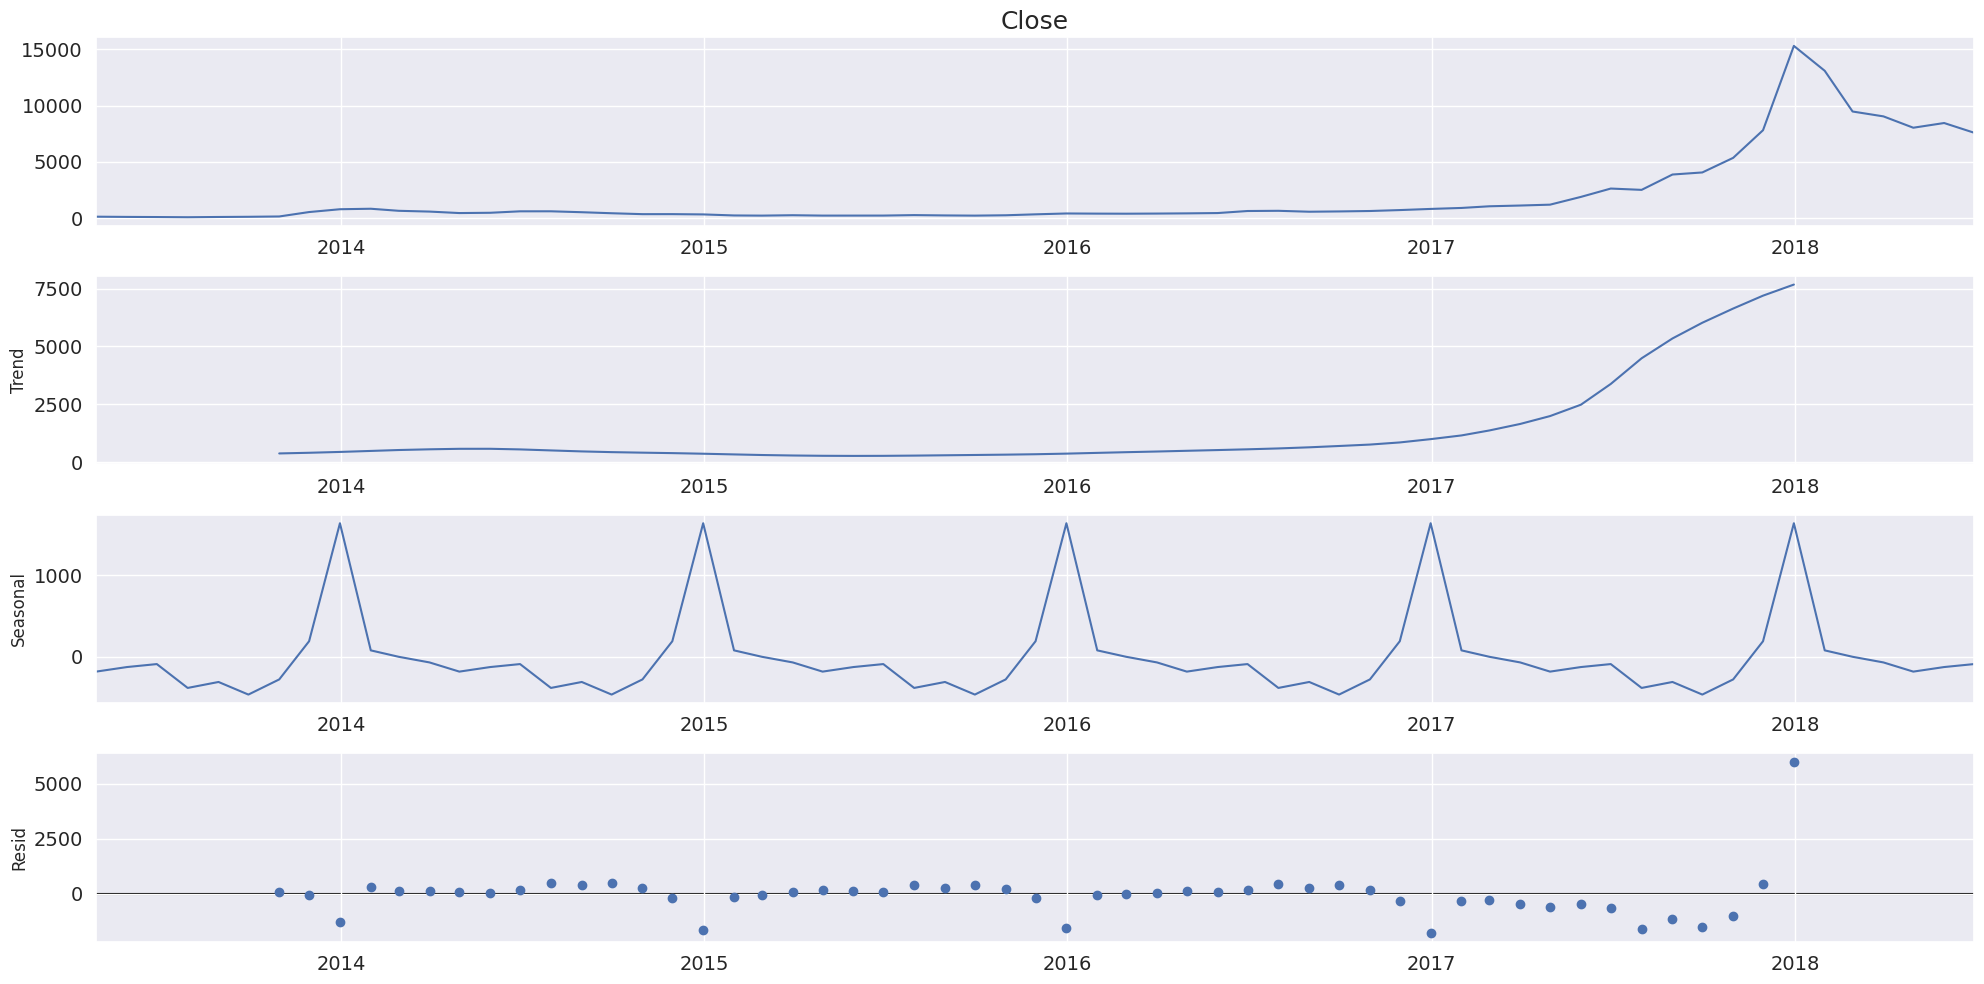

In [6]:
#seasonal_decompose(btc_month.close, freq=12).plot()
seasonal_decompose(btc_month.Close, model='additive').plot()
print("Dickey–Fuller test: p=%f" % adfuller(btc_month.Close)[1])

The p-value indicates that series is not stationary with 99.88% confidence.

Most interesting is the seasonal component which was extracted, which looks like it repeats itself on a yearly basis.

We can also see that the residuals are fairly constant until around the start of 2017, which is going to make forecasting difficult as we are still inside of this time period where the price is moving insanely.

However, lets proceed anyway.

## Box-Cox Transformation </a><a class="anchor" id="transformation"></a>

Lets use the Box-Cox transformation to suppress some of the variance.

The Box-Cox transformation is a family of power transformations indexed by a parameter lambda. Whenever you use it the parameter needs to be estimated from the data. In time series the process could have a non-constant variance. if the variance changes with time the process is nonstationary. It is often desirable to transform a time series to make it stationary. Sometimes after applying Box-Cox with a particular value of lambda the process may look stationary. It is sometimes possible that even if after applying the Box-Cox transformation the series does not appear to be stationary, diagnostics from ARIMA modeling can then be used to decide if differencing or seasonal differencing might be useful to to remove polynomial trends or seasonal trends respectively. After that the result might be an ARMA model that is stationary. If diagnostics confirm the orders p an q for the ARMA model, the AR and MA parameters can then be estimated.

The code applies a Box-Cox transformation to the 'Close' price of Bitcoin data, saving the transformed values in a new column 'close_box'. It then performs the Dickey-Fuller test on the transformed data to check for stationarity and prints the p-value.






In [7]:
# Box-Cox Transformations
btc_month['close_box'], lmbda = stats.boxcox(btc_month.Close)
print("Dickey–Fuller test: p=%f" % adfuller(btc_month.close_box)[1])

Dickey–Fuller test: p=0.509378


The p-value indicates that series is still not stationary.

## Differencing <a class="anchor" id="differencing"></a>

When building models to forecast time series data (like ARIMA), another pre-processing step is differencing the data (calculating sequentially xt−xt−1) until we get to a point where the series is stationary. Models account for oscillations but not for trends, and therefore, accounting for trends by differencing allows us to use the models that account for oscillations.

Once the model has been constructed, we can account for trends separately, by adding the trends component-wise.

### Seasonal differentiation  <a class="anchor" id="seasonal_differentiationn"></a>

One method of differencing data is seasonal differencing, which involves computing the difference between an observation and the corresponding observation in the previous year.

The code calculates the seasonal differentiation of the Box-Cox transformed 'Close' price by taking the difference between the value and its value 12 months ago. It then performs the Dickey-Fuller test on the differentiated data to check for stationarity and prints the p-value.






In [8]:
# Seasonal differentiation (12 months)
btc_month['box_diff_seasonal_12'] = btc_month.close_box - btc_month.close_box.shift(12)
print("Dickey–Fuller test: p=%f" % adfuller(btc_month.box_diff_seasonal_12[12:])[1])

Dickey–Fuller test: p=0.155278


The p-value indicates that series is still not stationary.

The code calculates the seasonal differentiation of the Box-Cox transformed 'Close' price by taking the difference between the value and its value 3 months ago. It then performs the Dickey-Fuller test on the differentiated data to check for stationarity and prints the p-value.






In [9]:
# Seasonal differentiation (3 months)
btc_month['box_diff_seasonal_3'] = btc_month.close_box - btc_month.close_box.shift(3)
print("Dickey–Fuller test: p=%f" % adfuller(btc_month.box_diff_seasonal_3[3:])[1])

Dickey–Fuller test: p=0.012923


The p-value indicates that series is stationary as the computed p-value is lower than the significance level alpha = 0.05.

### Regular differentiation  <a class="anchor" id="regular_differentiation"></a>

The code applies regular differentiation to the seasonally differentiated data by taking the difference between the value and its value one step ago. It then performs the STL-decomposition on the differentiated data and prints the p-value of the Dickey-Fuller test to check for stationarity.






Dickey–Fuller test: p=0.081588


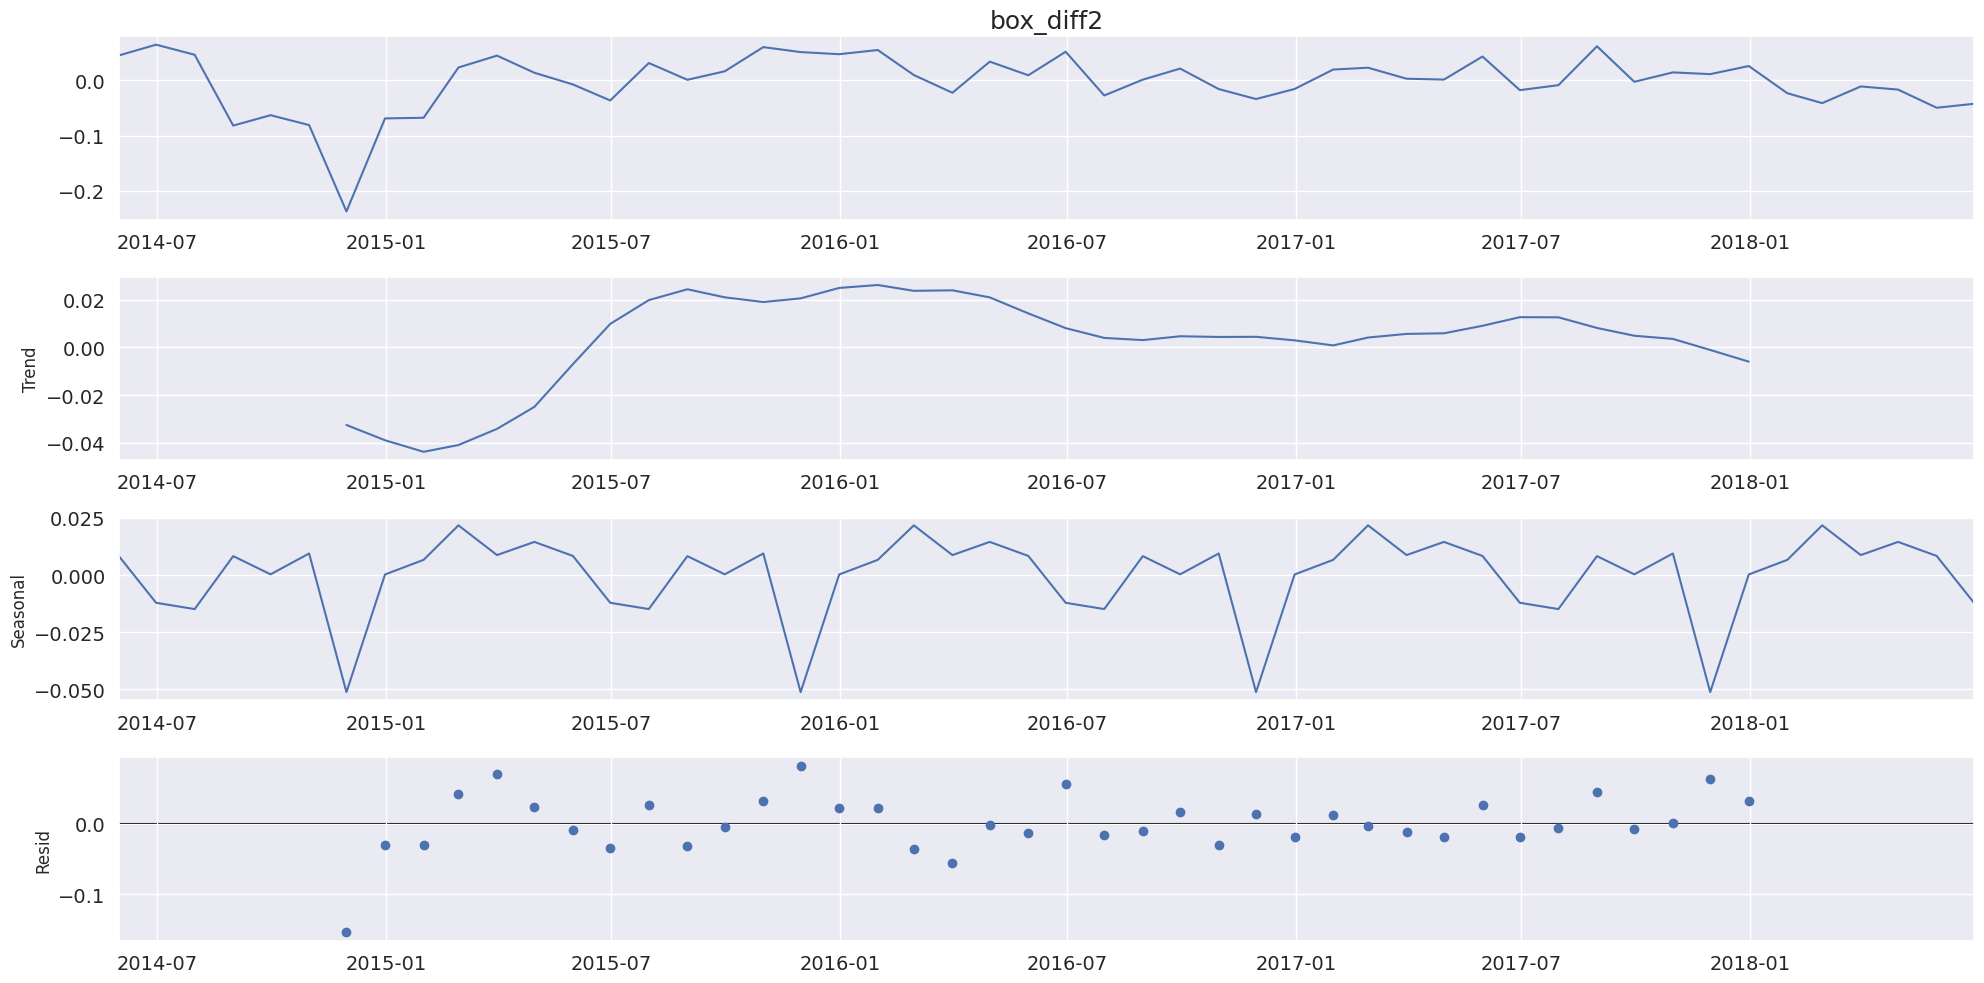

In [10]:
# Regular differentiation
btc_month['box_diff2'] = btc_month.box_diff_seasonal_12 - btc_month.box_diff_seasonal_12.shift(1)

# STL-decomposition
seasonal_decompose(btc_month.box_diff2[13:]).plot()
print("Dickey–Fuller test: p=%f" % adfuller(btc_month.box_diff2[13:])[1])

The p-value indicates that series is stationary as the computed p-value is lower than the significance level alpha = 0.05.

### Autocorrelation  <a class="anchor" id="autocorrelation"></a>

The code generates an autocorrelation plot for the 'Close' column of the monthly Bitcoin data. It uses a maximum of 12 lags in the plot, and 'tight_layout()' is used to optimize the plot's layout.






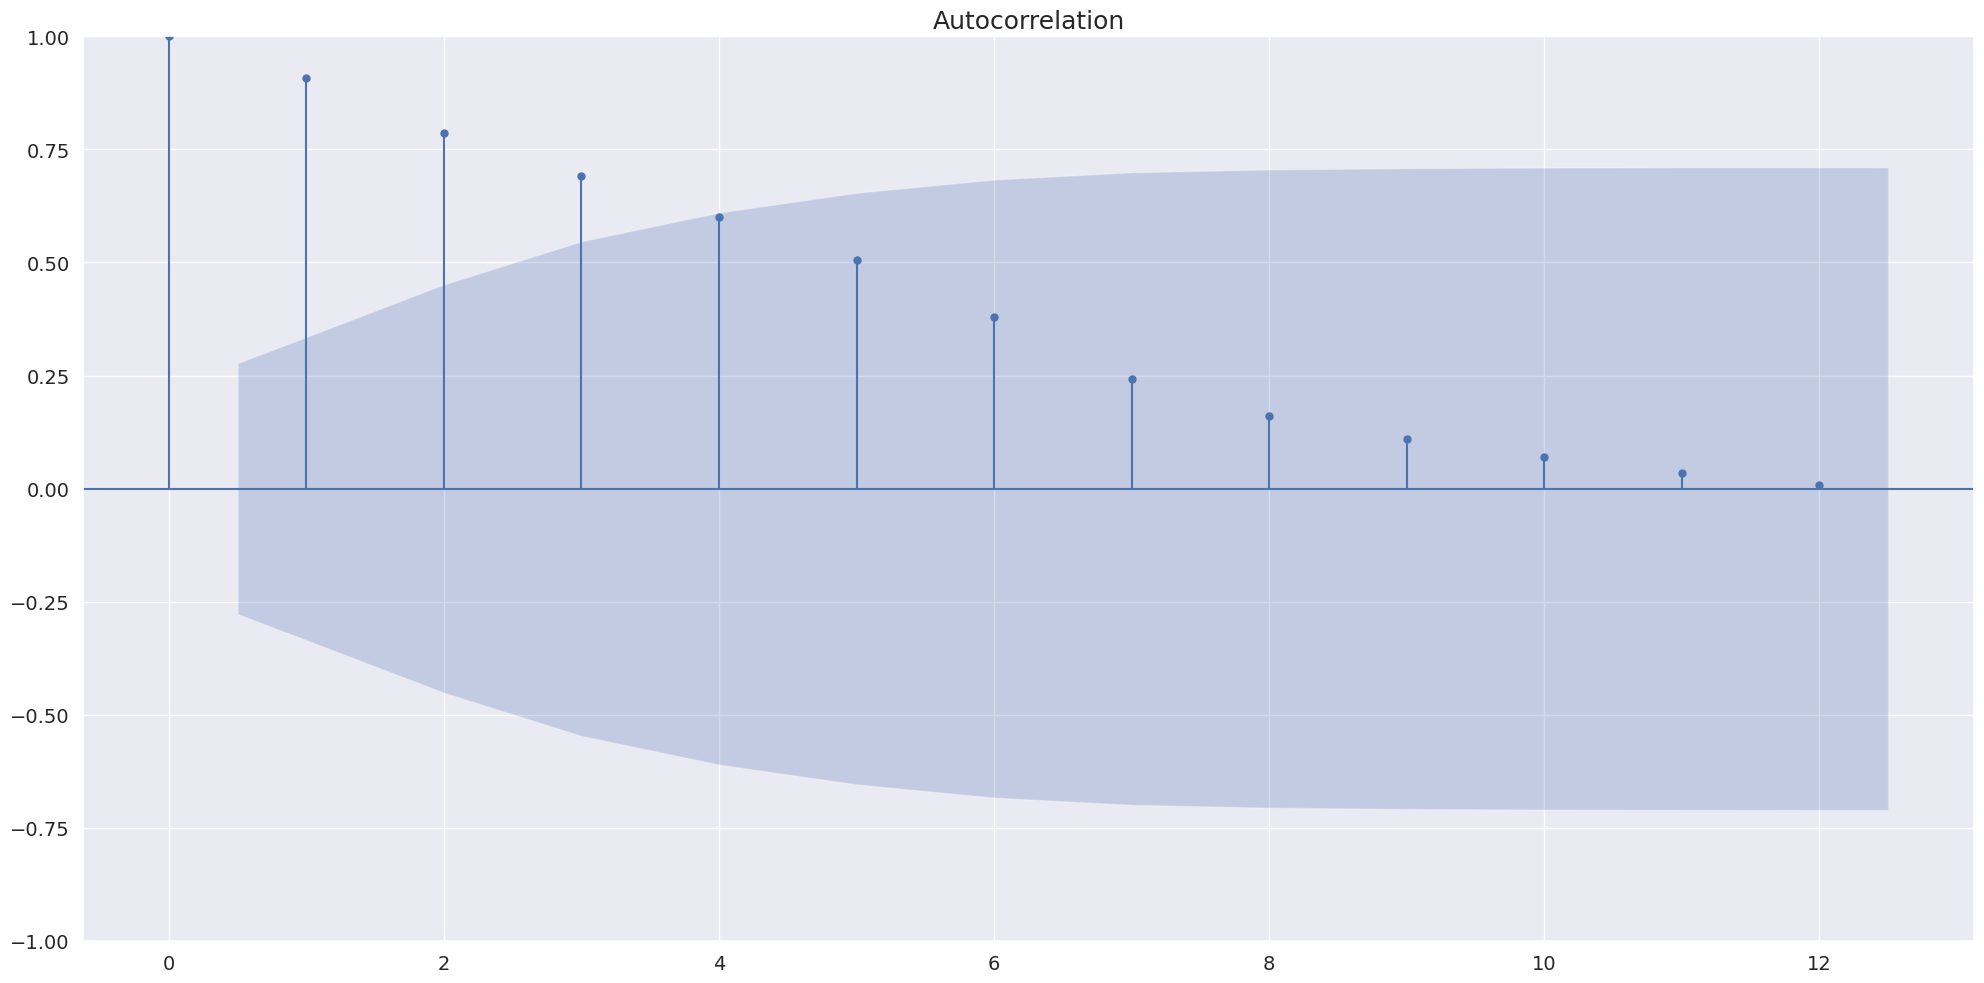

In [11]:
#autocorrelation_plot(btc_month.close)
plot_acf(btc_month.Close[13:].values.squeeze(), lags=12)
plt.tight_layout()

The code creates two subplots: the first plot shows the autocorrelation function (ACF) and the second plot shows the partial autocorrelation function (PACF) for the 'box_diff2' column of the Bitcoin monthly data. It uses a maximum of 12 lags in each plot and 'tight_layout()' is used to optimize the layout.






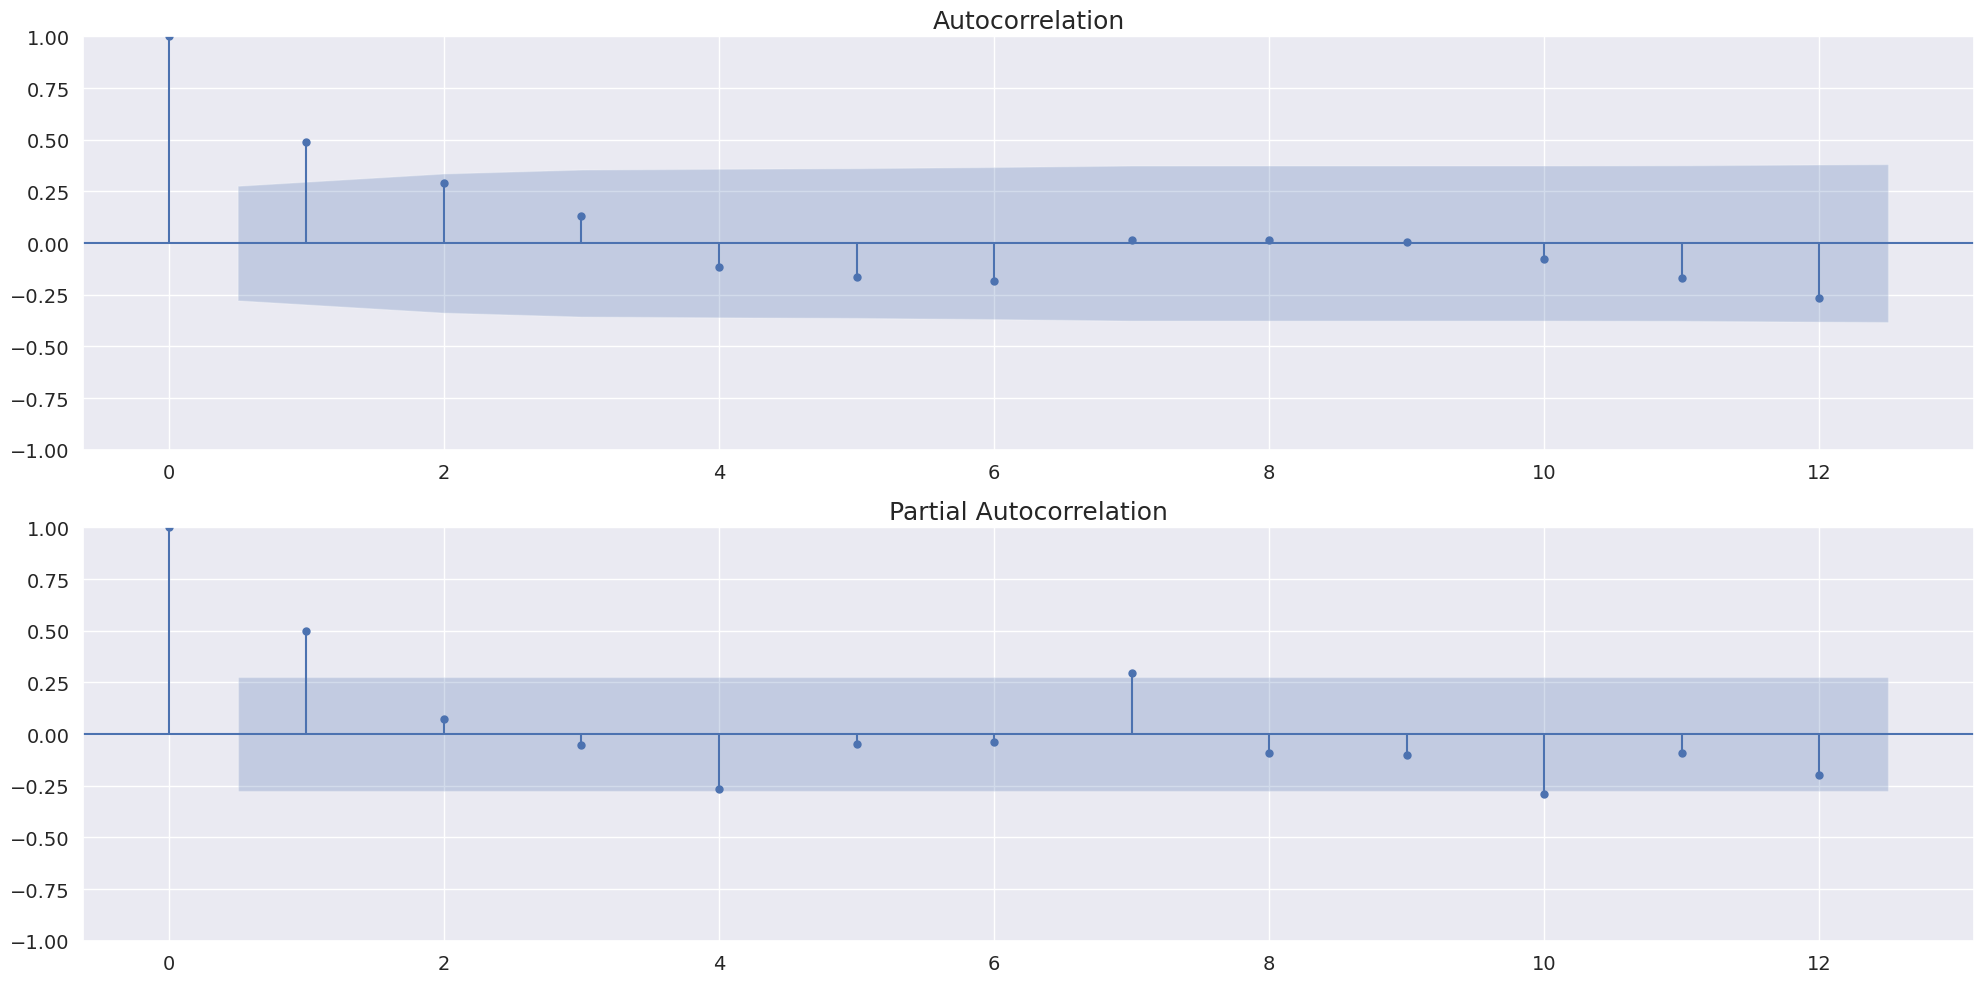

In [12]:
# Initial approximation of parameters using Autocorrelation and Partial Autocorrelation Plots
ax = plt.subplot(211)
# Plot the autocorrelation function
#sm.graphics.tsa.plot_acf(btc_month.box_diff2[13:].values.squeeze(), lags=48, ax=ax)
plot_acf(btc_month.box_diff2[13:].values.squeeze(), lags=12, ax=ax)
ax = plt.subplot(212)
#sm.graphics.tsa.plot_pacf(btc_month.box_diff2[13:].values.squeeze(), lags=48, ax=ax)
plot_pacf(btc_month.box_diff2[13:].values.squeeze(), lags=12, ax=ax)
plt.tight_layout()

# Monthly Forecasting <a class="anchor" id="monthly_forecasting"></a>

## ARIMA Model  <a class="anchor" id="arima_model"></a>
AutoRegressive Integrated Moving Average

ARIMA models are denoted with the notation ARIMA(p, d, q). These parameters account for seasonality, trend, and noise in datasets:

    p - the number of lag observations to include in the model, or lag order. (AR)
    d - the number of times that the raw observations are differenced, or the degree of differencing. (I)
    q - the size of the moving average window, also called the order of moving average.(MA)

A linear regression model is constructed including the specified number and type of terms, and the data is prepared by a degree of differencing in order to make it stationary, i.e. to remove trend and seasonal structures that negatively affect the regression model.
A value of 0 for a parameter indicates to not use that element of the model.

#### Parameter Selection

We will iteratively explore different combinations of parameters. For each combination we fit a new ARIMA model with SARIMAX() and assess its overall quality.

We will use the AIC (Akaike Information Criterion) value, returned with ARIMA models fitted using statsmodels. The AIC measures how well a model fits the data while taking into account the overall complexity of the model. A model that fits the data very well while using lots of features will be assigned a larger AIC score than a model that uses fewer features to achieve the same goodness-of-fit. Therefore, we are interested in finding the model that yields the lowest AIC value.

---
## Step 1 & 2: Time Series Pipeline (PyCaret)

Automated time series pipeline with PyCaret:
- `setup()` → preprocessing & configuration
- `compare_models()` → model selection
- `finalize_model()` → train on full data


In [ ]:
from pycaret.time_series import *

ts_setup = setup(data=df, target='Close', fh=12, session_id=42, verbose=False)

# Compare models and select best
best_model = compare_models()

# Display comparison results
print(best_model)


In [ ]:
# Plot forecast
plot_model(best_model, plot='forecast')


In [ ]:
# Finalize the model
final_model = finalize_model(best_model)

# Make predictions
predictions = predict_model(final_model)
print(predictions)